In [1]:
from google.colab import drive
drive.mount('/content/drive')


import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Mounted at /content/drive


In [2]:
base_path = '/content/drive/MyDrive/Dataset/'
csv_path = base_path + 'Data_Entry_2017_v2020.csv'
images_dir = base_path + 'images/'


df = pd.read_csv(csv_path)
print("Data loaded! Here's a preview:")
print(df.head())


# Binary label: Normal vs Findings
df['label'] = df['Finding Labels'].apply(lambda x: 'Normal' if x=='No Finding' else 'Findings')


# Full path for images
df['image_path'] = images_dir + df['Image Index']


# ✅ Filter out missing files
df = df[df['image_path'].apply(os.path.exists)]
print("Remaining images after filtering:", len(df))

Data loaded! Here's a preview:
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_001.png                  Hernia            0           3   

   Patient Age Patient Sex View Position  OriginalImage[Width  Height]  \
0           57           M            PA                 2682     2749   
1           58           M            PA                 2894     2729   
2           58           M            PA                 2500     2048   
3           80           M            PA                 2500     2048   
4           74           F            PA                 2500     2048   

   OriginalImagePixelSpacing[x     y]  
0                        0.143  0.143  
1          

In [3]:
from sklearn.model_selection import train_test_split


train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)


print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

Train: 3999 Val: 500 Test: 500


In [4]:
import tensorflow as tf


IMG_SIZE = (256, 256)
BATCH_SIZE = 32


def preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label


def create_dataset(dataframe):
    paths = dataframe['image_path'].values
    labels = (dataframe['label'].values == 'Findings').astype(int)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = create_dataset(train_df)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

In [5]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models


base_model = EfficientNetB0(
weights="imagenet",
include_top=False,
input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)


base_model.trainable = False # freeze base model


model = models.Sequential([
base_model,
layers.GlobalAveragePooling2D(),
layers.Dropout(0.4),
layers.Dense(1, activation="sigmoid")
])


model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
loss="binary_crossentropy",
metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)


model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1
)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1179s 7s/step - accuracy: 0.5331 - auc: 0.5053 - loss: 0.6961 - val_accuracy: 0.5540 - val_auc: 0.5000 - val_loss: 0.6879


In [8]:
test_loss, test_acc, test_auc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.2f}, Test AUC: {test_auc:.2f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 118s 50ms/step - accuracy: 0.5412 - auc: 0.5000 - loss: 0.6898
Test Accuracy: 0.55, Test AUC: 0.50


In [10]:
base_model.trainable = True # unfreeze for fine-tuning


model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
loss="binary_crossentropy",
metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)


history_fine = model.fit(
train_ds,
validation_data=val_ds,
epochs=1
)

125/125 ━━━━━━━━━━━━━━━━━━━━ 212s 917ms/step - accuracy: 0.4938 - auc: 0.4951 - loss: 0.7125 - val_accuracy: 0.5500 - val_auc: 0.4818 - val_loss: 0.6918


In [15]:
# Explicitly define the input for feature_extractor
input_tensor = tf.keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Get the output of the base_model
base_model_output = base_model(input_tensor)

# Get the output of the GlobalAveragePooling2D layer
pooling_output = model.layers[-3](base_model_output)

feature_extractor = models.Model(
    inputs=input_tensor,
    outputs=pooling_output
)


# Extract embeddings for training images
train_paths = train_df['image_path'].values
train_embeddings = []


for path in train_paths:
  img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
  img_array = tf.keras.utils.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0) / 255.0
  emb = feature_extractor.predict(img_array, verbose=0)
  train_embeddings.append(emb.flatten())


train_embeddings = np.array(train_embeddings)

In [17]:
from sklearn.metrics.pairwise import cosine_similarity


def find_similar_images(query_path, top_k=5):
    img = tf.keras.utils.load_img(query_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    query_emb = feature_extractor.predict(img_array, verbose=0)

    sims = cosine_similarity(query_emb, train_embeddings)[0]
    indices = np.argsort(sims)[::-1][:top_k]
    return [train_paths[i] for i in indices], sims[indices]

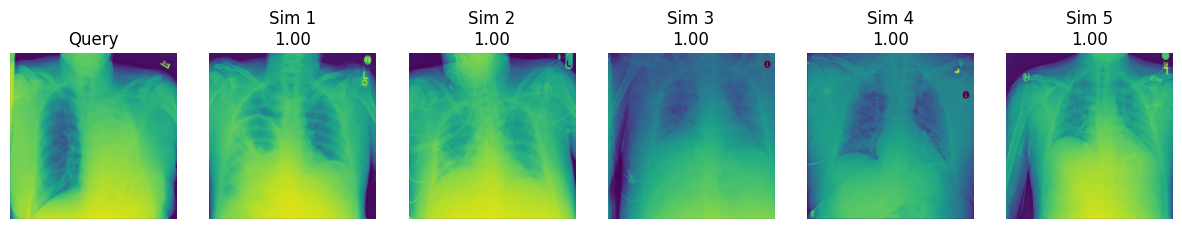

In [19]:
query_img = test_df['image_path'].iloc[0]
similar_paths, scores = find_similar_images(query_img, top_k=5)


plt.figure(figsize=(15, 5))
# Query image
plt.subplot(1, 6, 1)
plt.imshow(plt.imread(query_img))
plt.title("Query")
plt.axis("off")


# Similar images
for i, (path, score) in enumerate(zip(similar_paths, scores)):
    plt.subplot(1, 6, i+2)
    plt.imshow(plt.imread(path))
    plt.title(f"Sim {i+1}\n{score:.2f}")
    plt.axis("off")


plt.show()